# CMM-VAE - MSWEP DJF - Weighted Loss + Option B Holdout

Changes from v1 (cmmvae_mswep_djf_winter_groups):
- **Class imbalance fix:** Weighted cross-entropy in `target_loss` (inverse-frequency weights computed from training labels)
- **Holdout evaluation:** Option B — average probability predictions from all 5 fold models, then compute BSS once on the average

Everything else is identical to v1:
- `GroupShuffleSplit(70/30)` assigns whole winters to train/holdout
- `GroupKFold(5)` respects winters inside CV
- KMeans labels and Q95 threshold derived from training winters only

In [2]:
%load_ext autoreload
%autoreload 2

from keras.layers import Lambda, Input, Dense, Reshape
from keras.models import Model
from keras.losses import mse
from keras.metrics import categorical_crossentropy

import tensorflow as tf
from tensorflow.keras import backend as K

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.cluster import KMeans

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

import clustering_functions as cf
import skill_functions as sf
import preprocessing_functions as pf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Parameters

In [3]:
import os, random
import numpy as np
import tensorflow as tf

g0                         = 9.80665
djf_months                 = [12, 1, 2]

cluster_number             = 4
reconstruction_loss_factor = 0.5
filepath                   = "results/cmmvae_weighted_optionB/"

pr_cluster_number          = 4
original_dim               = 825          # Z500 Atlantic grid: 25 lat x 33 lon
inputdim1, inputdim2       = 25, 33
latent_dim                 = 15
activation_function        = 'relu'
dim_layer1, dim_layer2, dim_layer3 = 256, 128, 64
batch_size                 = 128
epochs                     = 100
n_splits                   = 5

HOLDOUT_FRAC  = 0.30    # 30% of winters -> holdout
RANDOM_STATE  = 42

input_shape   = (original_dim,)
input_shape_r = (pr_cluster_number,)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed(RANDOM_STATE)
os.makedirs(filepath, exist_ok=True)
print(f"Results will be saved to: {filepath}")

Results will be saved to: results/cmmvae_weighted_optionB/


### Sampling function

In [4]:
def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(
        shape=(K.shape(z_mean)[0], K.int_shape(z_mean)[1]),
        mean=0., stddev=1.)
    return z_mean + K.exp(0.5 * z_log_sigma) * epsilon

### Data pre-processing

**Load ERA5 Z500 (DJF, 1979-2020)**

In [5]:
z500 = pf.preprocess_dataset(
    filename              = '../data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
    variable_name         = 'z',
    multiplication_factor = 1 / g0,
    geographical_filter   = 'new atlantic',
    months_filter         = djf_months,
    anomalies             = True,
    normalization         = False,
    rolling_window        = 5)

z500 = z500.where(z500['time.year'] > 1978, drop=True)
z500 = z500.where(z500['time.year'] < 2021, drop=True)

weights = np.cos(np.deg2rad(z500.latitude))
z500    = z500 * weights
z500    = z500 / z500.std()

print(f"Z500 DJF shape: {z500.shape}")

Z500 DJF shape: (3791, 25, 33)


**Load raw MSWEP precipitation (DJF, 1979-2020)**

> Raw spatial data — labels and Q95 will be derived from training winters only.

In [6]:
pr_spatial = xr.open_dataset('../data.nosync/MSWEP_pr_total_DJF.nc')['precipitation']
pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2021, drop=True)

print(f"pr_spatial shape: {pr_spatial.shape}")
assert z500.shape[0] == pr_spatial.shape[0], (
    f"Time mismatch! Z500={z500.shape[0]}  MSWEP={pr_spatial.shape[0]}")
print("Time alignment OK.")

pr_spatial shape: (3791, 150, 160)
Time alignment OK.


### Build winter-year group key

> **Rule:** Dec of year Y + Jan/Feb of year Y+1 = **winter Y**  
> Example: Dec 1980, Jan 1981, Feb 1981 all get `winter_year = 1980`  
> This key is used to ensure those 3 months **always stay together**.

In [7]:
times = pd.to_datetime(z500.time.values)

# Dec of year Y -> winter Y  |  Jan/Feb of year Y -> winter Y-1
winter_year = np.array([t.year if t.month == 12 else t.year - 1
                        for t in times])

unique_winters = np.sort(np.unique(winter_year))
print(f"Total DJF days  : {len(times)}")
print(f"Unique winters  : {len(unique_winters)}")
print(f"Period          : winter {unique_winters[0]}/{unique_winters[0]+1} "
      f"to winter {unique_winters[-1]}/{unique_winters[-1]+1}")

Total DJF days  : 3791
Unique winters  : 43
Period          : winter 1978/1979 to winter 2020/2021


### Train / holdout split (GroupShuffleSplit, 70 % / 30 %)

> `GroupShuffleSplit` with `groups=winter_year` guarantees that  
> **all days of a given winter land in the same set**.  
> December 1980, January 1981, February 1981 will ALWAYS be together.

In [8]:
X = cf.reshape_data_for_clustering(z500)   # (n_days, 825)

gss = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE)
train_idx, holdout_idx = next(gss.split(X, groups=winter_year))

train_winters   = sorted(set(winter_year[train_idx].tolist()))
holdout_winters = sorted(set(winter_year[holdout_idx].tolist()))

print(f"Total days    : {len(X)}")
print(f"Training days : {len(train_idx)}   ({len(train_winters)} winters)")
print(f"Holdout  days : {len(holdout_idx)}   ({len(holdout_winters)} winters)")

# Verify no DJF is split across sets
overlap = set(train_winters) & set(holdout_winters)
print(f"Winter overlap: {len(overlap)}  {'<- LEAKAGE!' if overlap else '<- CLEAN (no DJF split)'}")

Total days    : 3791
Training days : 2619   (30 winters)
Holdout  days : 1172   (13 winters)
Winter overlap: 0  <- CLEAN (no DJF split)


### Training and holdout winters — full list

> Printed **before any training** so you can verify the split.

In [9]:
print("=" * 65)
print(f"  TRAINING SET  ({len(train_winters)} winters = ~70 %)")
print("=" * 65)
for w in train_winters:
    n_days = int(np.sum(winter_year[train_idx] == w))
    print(f"  Winter {w}/{w+1-2000:02d}   Dec {w} + Jan/Feb {w+1}   ({n_days} days)")

print()
print("=" * 65)
print(f"  HOLDOUT SET  ({len(holdout_winters)} winters = ~30 %)")
print("=" * 65)
for w in holdout_winters:
    n_days = int(np.sum(winter_year[holdout_idx] == w))
    print(f"  Winter {w}/{w+1-2000:02d}   Dec {w} + Jan/Feb {w+1}   ({n_days} days)")

print()
print(f"Total training days : {len(train_idx)}  "
      f"({100*len(train_idx)/(len(train_idx)+len(holdout_idx)):.1f} %)")
print(f"Total holdout  days : {len(holdout_idx)}  "
      f"({100*len(holdout_idx)/(len(train_idx)+len(holdout_idx)):.1f} %)")

  TRAINING SET  (30 winters = ~70 %)
  Winter 1978/-21   Dec 1978 + Jan/Feb 1979   (59 days)
  Winter 1979/-20   Dec 1979 + Jan/Feb 1980   (91 days)
  Winter 1980/-19   Dec 1980 + Jan/Feb 1981   (90 days)
  Winter 1983/-16   Dec 1983 + Jan/Feb 1984   (91 days)
  Winter 1985/-14   Dec 1985 + Jan/Feb 1986   (90 days)
  Winter 1987/-12   Dec 1987 + Jan/Feb 1988   (91 days)
  Winter 1988/-11   Dec 1988 + Jan/Feb 1989   (90 days)
  Winter 1989/-10   Dec 1989 + Jan/Feb 1990   (90 days)
  Winter 1991/-8   Dec 1991 + Jan/Feb 1992   (91 days)
  Winter 1992/-7   Dec 1992 + Jan/Feb 1993   (90 days)
  Winter 1993/-6   Dec 1993 + Jan/Feb 1994   (90 days)
  Winter 1994/-5   Dec 1994 + Jan/Feb 1995   (90 days)
  Winter 1995/-4   Dec 1995 + Jan/Feb 1996   (91 days)
  Winter 1996/-3   Dec 1996 + Jan/Feb 1997   (90 days)
  Winter 1997/-2   Dec 1997 + Jan/Feb 1998   (90 days)
  Winter 1998/-1   Dec 1998 + Jan/Feb 1999   (90 days)
  Winter 1999/00   Dec 1999 + Jan/Feb 2000   (91 days)
  Winter 2000/01   D

### Recompute precipitation labels — training winters only

> KMeans **fit only on training precipitation**.  
> Holdout days labelled by transforming with the frozen model.

In [10]:
pr_values = pr_spatial.values            # (n_days, ny, nx)
nt, ny, nx = pr_values.shape
pr_flat = np.reshape(pr_values, [nt, ny * nx], order='F')

pr_flat_train   = pr_flat[train_idx]
pr_flat_holdout = pr_flat[holdout_idx]

print(f"Fitting KMeans (k={pr_cluster_number}) on {len(train_idx)} training days ...")
kmeans = KMeans(n_clusters=pr_cluster_number, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(pr_flat_train)

pr_labels_train   = kmeans.predict(pr_flat_train)
pr_labels_holdout = kmeans.predict(pr_flat_holdout)
pr_labels_all     = kmeans.predict(pr_flat)

print("Training label dist: " +
      "  ".join([f"c{k}={np.sum(pr_labels_train==k)}" for k in range(pr_cluster_number)]))
print("Holdout  label dist: " +
      "  ".join([f"c{k}={np.sum(pr_labels_holdout==k)}" for k in range(pr_cluster_number)]))

Fitting KMeans (k=4) on 2619 training days ...
Training label dist: c0=1850  c1=493  c2=167  c3=109
Holdout  label dist: c0=781  c1=268  c2=68  c3=55


In [11]:
# --- CLASS WEIGHTS (inverse frequency, normalized so mean weight = 1) ---
# Computed from training labels so no holdout leakage.
counts           = np.array([np.sum(pr_labels_train == k)
                             for k in range(pr_cluster_number)], dtype=np.float32)
class_weights_np = len(pr_labels_train) / (pr_cluster_number * counts)
class_weights_np = class_weights_np / class_weights_np.mean()   # mean = 1
class_weights_tf = tf.constant(class_weights_np, dtype=tf.float32)

print('Class weights (inverse frequency, normalized):')
for k in range(pr_cluster_number):
    print(f'  c{k}: count={int(counts[k])}  weight={class_weights_np[k]:.3f}')

Class weights (inverse frequency, normalized):
  c0: count=1850  weight=0.122
  c1: count=493  weight=0.458
  c2: count=167  weight=1.351
  c3: count=109  weight=2.070


**Build one-hot label matrices**

In [12]:
def to_onehot(labels, n_classes):
    oh = np.zeros((len(labels), n_classes), dtype=np.float32)
    oh[np.arange(len(labels)), labels] = 1.0
    return oh

y_train   = to_onehot(pr_labels_train,   pr_cluster_number)
y_holdout = to_onehot(pr_labels_holdout, pr_cluster_number)
y_all     = to_onehot(pr_labels_all,     pr_cluster_number)

X_train_full = X[train_idx]
X_holdout    = X[holdout_idx]

dummy_train  = np.ones((X_train_full.shape[0], 1))
dummy_holdout= np.ones((X_holdout.shape[0],    1))
dummy_full   = np.ones((X.shape[0],            1))

print(f"X_train : {X_train_full.shape}   y_train : {y_train.shape}")
print(f"X_holdout: {X_holdout.shape}   y_holdout: {y_holdout.shape}")

X_train : (2619, 825)   y_train : (2619, 4)
X_holdout: (1172, 825)   y_holdout: (1172, 4)


### Q95 exceedance mask — training winters only

> Per-pixel 95th percentile computed exclusively from training days.  
> The same threshold is applied to holdout days for evaluation.

In [13]:
q95_threshold = np.percentile(pr_flat_train, 95, axis=0)   # (n_pixels,)

exceed_train   = (pr_flat_train   >= q95_threshold).astype(np.float32)
exceed_holdout = (pr_flat_holdout >= q95_threshold).astype(np.float32)
exceed_all     = (pr_flat         >= q95_threshold).astype(np.float32)

def flat_to_xarray(flat_exceed, time_coords, pr_ref):
    data_3d = np.reshape(flat_exceed, [len(time_coords), ny, nx], order='F')
    return xr.DataArray(
        data_3d,
        coords={'time': time_coords,
                'latitude':  pr_ref.latitude.values,
                'longitude': pr_ref.longitude.values},
        dims=['time', 'latitude', 'longitude'],
        name='precipitation')

threshold_qn95_train   = flat_to_xarray(exceed_train,   pr_spatial.time[train_idx],   pr_spatial)
threshold_qn95_holdout = flat_to_xarray(exceed_holdout, pr_spatial.time[holdout_idx], pr_spatial)
threshold_qn95_all     = flat_to_xarray(exceed_all,     pr_spatial.time,              pr_spatial)

print(f"Q95 threshold computed from {len(train_idx)} training days.")
print(f"Fraction exceeding in training : {exceed_train.mean():.3f}  (expect ~0.05)")
print(f"Fraction exceeding in holdout  : {exceed_holdout.mean():.3f}")

Q95 threshold computed from 2619 training days.
Fraction exceeding in training : 0.051  (expect ~0.05)
Fraction exceeding in holdout  : 0.046


## Define model

**Encoder**

In [14]:
inputs_x  = Input(shape=input_shape,   name='encoder_input')
inputs_r  = Input(shape=input_shape_r, name='ground_truth')

inter_x1  = Dense(dim_layer1, activation=activation_function)(inputs_x)
inter_x2  = Dense(dim_layer2, activation=activation_function)(inter_x1)
inter_x3  = Dense(dim_layer3, activation=activation_function)(inter_x2)

dummy_inp = Input(shape=(1,), name='dummy')
mu_vector = Dense(cluster_number * latent_dim, use_bias=False)(dummy_inp)
mu        = Reshape((cluster_number, latent_dim))(mu_vector)

pi  = Dense(cluster_number, activation='softmax', name='pi')(dummy_inp)
c   = Dense(cluster_number, activation='softmax', name='c')(inter_x3)

z_mean    = Dense(latent_dim, name='z_mean')(inter_x3)
z_log_var = Dense(latent_dim, name='z_log_var')(inter_x3)

r  = Dense(pr_cluster_number, activation='softmax', name='r_label')(inter_x3)
cr = Dense(cluster_number,    activation='softmax', name='cr')(r)

z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

encoder = Model([inputs_x, dummy_inp, inputs_r],
                [z_mean, z_log_var, z, mu, c, pi, r, cr], name='encoder')
encoder.summary()


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 256)                  211456    ['encoder_input[0][0]']       
                                                                                                  
 dense_1 (Dense)             (None, 128)                  32896     ['dense[0][0]']               
                                                                                                  
 dense_2 (Dense)             (None, 64)                   8256      ['dense_1[0][0]']             
                                                                                           

**Decoder**

In [15]:
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')

inter_y1 = Dense(dim_layer3, activation=activation_function)(latent_inputs)
inter_y2 = Dense(dim_layer2, activation=activation_function)(inter_y1)
inter_y3 = Dense(dim_layer1, activation=activation_function)(inter_y2)
outputs  = Dense(original_dim)(inter_y3)

decoder  = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 15)]              0         
                                                                 
 dense_4 (Dense)             (None, 64)                1024      
                                                                 
 dense_5 (Dense)             (None, 128)               8320      
                                                                 
 dense_6 (Dense)             (None, 256)               33024     
                                                                 
 dense_7 (Dense)             (None, 825)               212025    
                                                                 
Total params: 254393 (993.72 KB)
Trainable params: 254393 (993.72 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Full VAE and loss function**

In [16]:
outputs_vae = decoder(encoder([inputs_x, dummy_inp, inputs_r])[2])
vae         = Model([inputs_x, dummy_inp, inputs_r], outputs_vae, name='vae_mlp')

reconstruction_loss = mse(inputs_x, outputs_vae) * original_dim * reconstruction_loss_factor
prediction_loss     = categorical_crossentropy(c, cr)

# Weighted target loss: penalises errors on minority precipitation clusters more.
# sample_weight picks the class weight for each sample via the one-hot inputs_r.
sample_weight = tf.reduce_sum(inputs_r * class_weights_tf, axis=-1)            # (batch,)
ce_supervised = -tf.reduce_sum(
    inputs_r * tf.math.log(tf.clip_by_value(r, 1e-7, 1.0)), axis=-1)           # (batch,)
entropy_r     = -tf.reduce_sum(
    r        * tf.math.log(tf.clip_by_value(r, 1e-7, 1.0)), axis=-1)           # (batch,)
target_loss   = (sample_weight * ce_supervised + entropy_r) * pr_cluster_number

# Accumulators initialised as Python 0.0 so the first tensor addition
# sets the correct shape -- avoids the (batch,1)+(batch,)->(batch,batch) broadcast bug.
kl_loss_all   = 0.0   # will become shape (batch,) after first iteration
kl_cat_all    = 0.0   # will become scalar
dir_prior_all = 0.0   # will become shape (batch,) after first iteration

for i in range(cluster_number):
    kl_loss = 1 + z_log_var - tf.math.square(z_mean - mu[:, i, :]) - tf.math.exp(z_log_var)
    kl_loss = tf.multiply(tf.reduce_sum(kl_loss, axis=-1), c[:, i])
    kl_loss_all = kl_loss_all + (-0.5 * kl_loss)

    mc  = tf.reduce_mean(c[:, i]);  mpi = tf.reduce_mean(pi[:, i])
    kl_cat_all    = kl_cat_all    + mc * tf.math.log(mc) - mc * tf.math.log(mpi)
    dir_prior_all = dir_prior_all + (-tf.math.log(pi[:, i]) * 0.5)

vae_loss = K.mean(reconstruction_loss + prediction_loss + target_loss +
                  kl_loss_all + kl_cat_all + dir_prior_all)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

vae.save_weights(filepath + 'random_weights_' + str(cluster_number) + '.h5')
print('Random weights saved.')



Random weights saved.


## Training — 5-Fold GroupKFold (training winters only)

> `GroupKFold` with `groups=winter_year[train_idx]` ensures each fold  
> also respects winter boundaries — no DJF split inside CV either.  
> The holdout set is **never touched** during this phase.

In [17]:
gkf = GroupKFold(n_splits=n_splits)
winter_year_train = winter_year[train_idx]

best_val_loss     = float('inf')
best_fold         = -1
fold_histories    = []
out_of_fold_preds = np.zeros_like(y_train, dtype=np.float32)

for fold, (cv_tr_idx, cv_val_idx) in enumerate(
        gkf.split(X_train_full, groups=winter_year_train)):

    print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
    cv_tr_winters  = sorted(set(winter_year_train[cv_tr_idx].tolist()))
    cv_val_winters = sorted(set(winter_year_train[cv_val_idx].tolist()))
    print(f"  CV-train winters: {cv_tr_winters}")
    print(f"  CV-val   winters: {cv_val_winters}")

    X_cv_tr,  X_cv_val  = X_train_full[cv_tr_idx],  X_train_full[cv_val_idx]
    y_cv_tr,  y_cv_val  = y_train[cv_tr_idx],        y_train[cv_val_idx]
    d_cv_tr  = np.ones((X_cv_tr.shape[0],  1))
    d_cv_val = np.ones((X_cv_val.shape[0], 1))

    vae.load_weights(filepath + 'random_weights_' + str(cluster_number) + '.h5')

    history = vae.fit(
        [X_cv_tr, d_cv_tr, y_cv_tr],
        [X_cv_tr, d_cv_tr, y_cv_tr],
        epochs     = epochs,
        batch_size = batch_size,
        validation_data=([X_cv_val, d_cv_val, y_cv_val],
                         [X_cv_val, d_cv_val, y_cv_val]),
        verbose=0)

    fold_histories.append(history.history)

    # OOF predictions for validation days (never seen by this fold)
    [_, _, _, _, c_cv_val_pred, _, _, _] = encoder.predict(
        [X_cv_val, d_cv_val, y_cv_val], batch_size=batch_size, verbose=0)

    # Align this fold's cluster columns to wettest->driest order
    # using cv_train predictions + cv_train precipitation.
    # This makes OOF rows from all folds share a consistent column meaning.
    [_, _, _, _, c_cv_tr_pred, _, _, _] = encoder.predict(
        [X_cv_tr, d_cv_tr, y_cv_tr], batch_size=batch_size, verbose=0)
    labels_cv_tr   = np.argmax(c_cv_tr_pred, axis=1)
    pr_cv_tr       = pr_flat_train[cv_tr_idx]
    precip_fold    = [np.sum(pr_cv_tr[labels_cv_tr == k]) if (labels_cv_tr == k).any() else 0.0
                      for k in range(cluster_number)]
    col_order_fold = np.argsort(precip_fold)[::-1]          # wettest first
    out_of_fold_preds[cv_val_idx] = c_cv_val_pred[:, col_order_fold]

    val_loss = history.history['val_loss'][-1]
    print(f"  Fold {fold + 1} final val_loss = {val_loss:.4f}")
    vae.save_weights(filepath + f'weights_{cluster_number}_fold{fold + 1}.h5')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_fold     = fold + 1

print(f"\nBest fold: {best_fold}  |  val_loss = {best_val_loss:.4f}")
vae.load_weights(filepath + f'weights_{cluster_number}_fold{best_fold}.h5')
vae.save_weights(filepath + f'final_weights_{cluster_number}.h5')
print("Best weights saved.")



--- FOLD 1/5 ---
  CV-train winters: [1978, 1979, 1980, 1983, 1985, 1987, 1989, 1992, 1993, 1994, 1996, 1997, 1999, 2000, 2001, 2004, 2007, 2008, 2010, 2011, 2013, 2016, 2019, 2020]
  CV-val   winters: [1988, 1991, 1995, 1998, 2006, 2018]
  Fold 1 final val_loss = 65.5482

--- FOLD 2/5 ---
  CV-train winters: [1978, 1979, 1985, 1987, 1988, 1991, 1992, 1993, 1994, 1995, 1997, 1998, 2000, 2001, 2004, 2006, 2007, 2010, 2011, 2013, 2016, 2018, 2019, 2020]
  CV-val   winters: [1980, 1983, 1989, 1996, 1999, 2008]
  Fold 2 final val_loss = 68.7052

--- FOLD 3/5 ---
  CV-train winters: [1980, 1983, 1985, 1988, 1989, 1991, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2001, 2004, 2006, 2007, 2008, 2011, 2013, 2016, 2018, 2019, 2020]
  CV-val   winters: [1978, 1979, 1987, 1992, 2000, 2010]
  Fold 3 final val_loss = 76.1011

--- FOLD 4/5 ---
  CV-train winters: [1978, 1979, 1980, 1983, 1985, 1987, 1988, 1989, 1991, 1992, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2004, 2006, 2007, 2008, 2010, 2016, 2

#### Training loss curves per fold

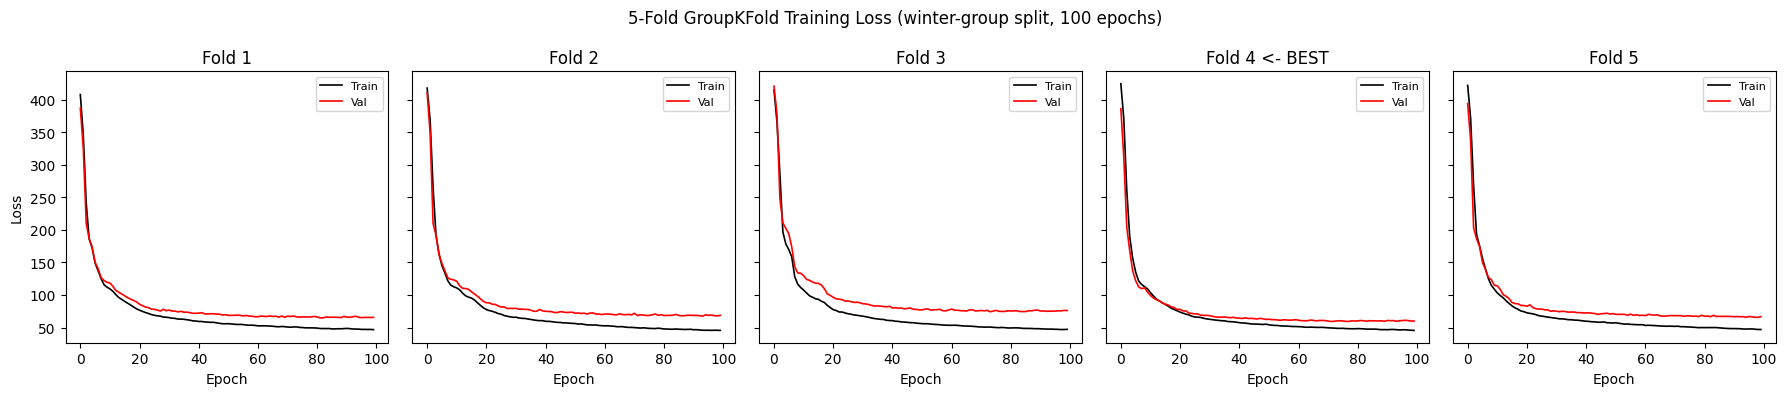

In [18]:
fig, axes = plt.subplots(1, n_splits, figsize=(18, 4), sharey=True)
for i, hist in enumerate(fold_histories):
    axes[i].plot(hist['loss'],     label='Train', color='black', linewidth=1.2)
    axes[i].plot(hist['val_loss'], label='Val',   color='red',   linewidth=1.2)
    marker = ' <- BEST' if i + 1 == best_fold else ''
    axes[i].set_title(f'Fold {i + 1}{marker}')
    axes[i].set_xlabel('Epoch')
    if i == 0: axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('5-Fold GroupKFold Training Loss (winter-group split, 100 epochs)', fontsize=12)
plt.tight_layout()
plt.savefig(filepath + 'kfold_loss_curves.png', dpi=150)
plt.show()

## Evaluation

**Encode full dataset with best fold weights**

In [19]:
print("Running encoder on full dataset...")
[z_mean_enc, z_log_var_enc, z_enc, mu_enc, c_enc, pi_enc, r_enc, cr_enc] = encoder.predict(
    [X, dummy_full, y_all], batch_size=batch_size, verbose=0)
print(f"c_enc shape: {c_enc.shape}")

Running encoder on full dataset...
c_enc shape: (3791, 4)


### Cluster assignment

In [20]:
final_labels = np.argmax(c_enc, axis=1).astype(float)
print("Cluster distribution (full 1979-2020):")
for k in range(cluster_number):
    n = (final_labels == k).sum()
    print(f"  Cluster {k}: {n} days  ({100*n/len(final_labels):.1f} %)")

Cluster distribution (full 1979-2020):
  Cluster 0: 895 days  (23.6 %)
  Cluster 1: 587 days  (15.5 %)
  Cluster 2: 977 days  (25.8 %)
  Cluster 3: 1332 days  (35.1 %)


### Re-order clusters by precipitation (wettest = Regime 1)

In [21]:
# Cluster ordering by precipitation -- training days only (leakage-free)
pr_total_train      = pr_spatial.isel(time=train_idx).sum(dim=['latitude', 'longitude']).values
final_labels_train  = final_labels[train_idx]
assert len(pr_total_train) == len(final_labels_train)

precip_sum = (pd.DataFrame({'values': pr_total_train, 'label': final_labels_train.astype(int)})
              .groupby('label')['values'].sum().reset_index()
              .rename(columns={'label': 'index_old'})
              .sort_values('values', ascending=False).reset_index(drop=True))
precip_sum['index_new'] = np.arange(len(precip_sum))

labels_reordered = final_labels.copy()
for i in range(len(final_labels)):
    labels_reordered[i] = precip_sum.loc[
        precip_sum['index_old'] == int(final_labels[i]), 'index_new'].values[0]

print(precip_sum)


   index_old      values  index_new
0          1  16828822.0          0
1          3   9198696.0          1
2          2   7408537.5          2
3          0   7343838.5          3


### Save cluster assignments

In [22]:
col_order = precip_sum['index_old'].values.tolist()
df_out = pd.DataFrame(data=c_enc)[col_order].copy()
df_out.columns = list(range(cluster_number))
df_out['label'] = labels_reordered.astype(int)
df_out.to_csv(filepath + 'c_enc_wgroups.csv', index=False)
print("Saved.")

Saved.


### Z500 Cluster Centres (precipitation-ordered)

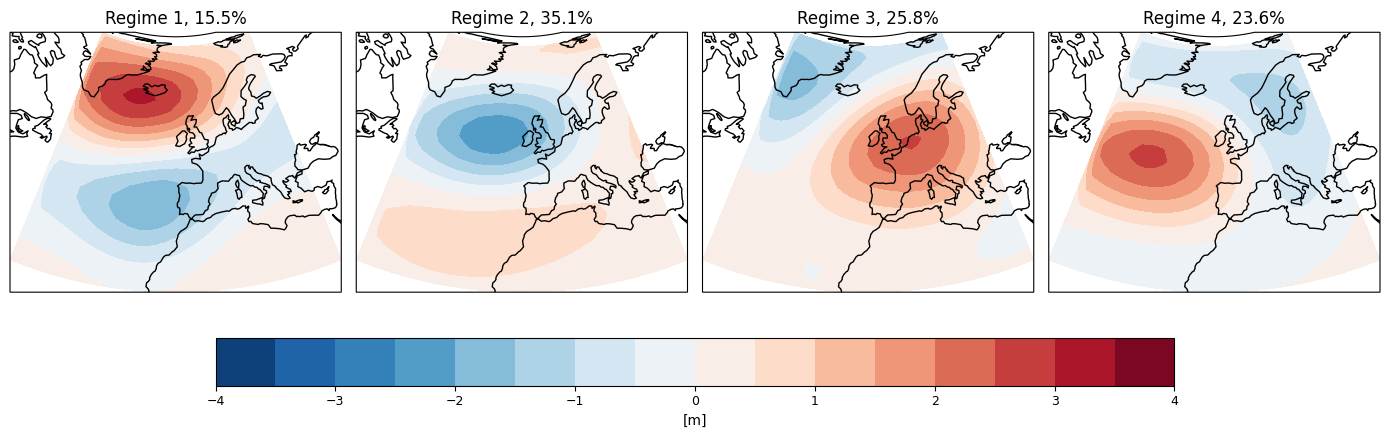

In [23]:
regime_names = [f'Regime {i+1}' for i in range(cluster_number)]

z500_lab = z500.assign_coords(label=('time', labels_reordered)) / weights
means    = z500_lab.groupby('label').mean()

cf.visualise_contourplot(
    cluster_centers = means,
    unit            = '[m]',
    regime_names    = regime_names,
    vmin=-4, vmax=4.5, steps=0.5,
    color_scheme    = 'RdBu_r',
    labels_data     = X,
    labels          = labels_reordered,
    borders         = False,
    col_number      = cluster_number,
    projection      = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

plt.savefig(filepath + 'cluster_centers.png', dpi=150)
plt.show()

### Precipitation Odds Ratio — full period (training-derived Q95)

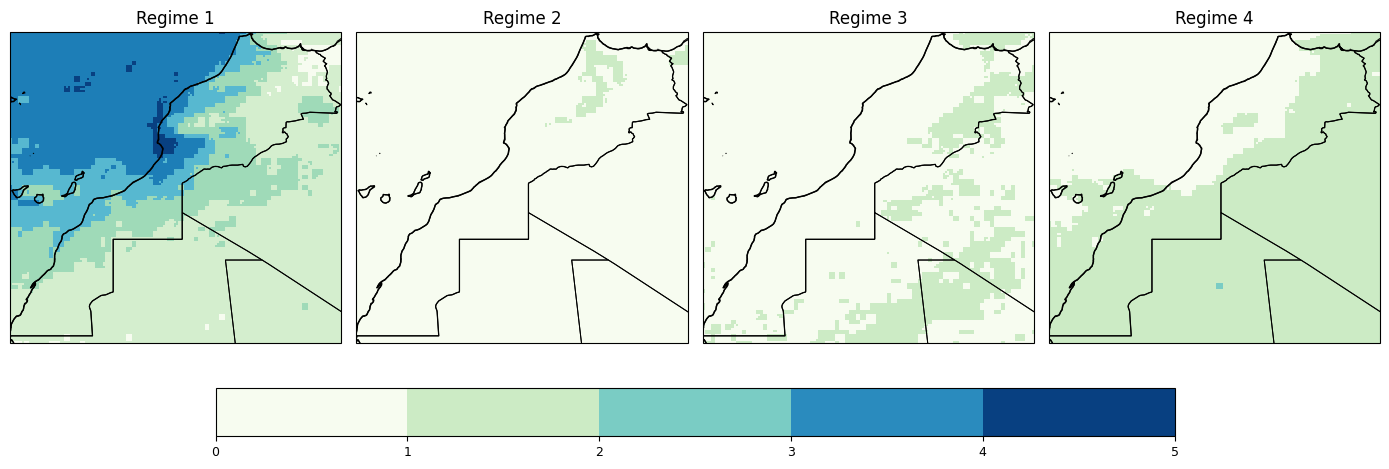

In [24]:
pr_qn95_ratio_full = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_all,
    labels           = labels_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_full,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin=0, vmax=5, steps=6,
    title          = 'Odds ratio - 95th percentile precipitation (full period)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_full.png', dpi=150)
plt.show()

---
## Holdout Set Evaluation (~30 % unseen winters)

> Model trained on ~70% winters via GroupKFold.  
> Now evaluated on the completely unseen holdout winters.
---

In [25]:
# --- OPTION B: Collect predictions from all 5 fold models, average, then score ---
# Each fold model may have different internal cluster numbering, so we re-derive
# the wettest->driest col_order from that fold's training predictions before
# stacking.  After averaging, column k = probability of being in the k-th wettest
# regime, so argmax gives a consistent label without further reordering.

print('Option B: averaging all 5 fold models on holdout...')
all_holdout_preds = []

for fold_num, (cv_tr_idx_f, _) in enumerate(
        gkf.split(X_train_full, groups=winter_year_train), start=1):

    vae.load_weights(filepath + f'weights_{cluster_number}_fold{fold_num}.h5')

    # Derive this fold's wettest->driest ordering from its training predictions
    X_cv_tr_f = X_train_full[cv_tr_idx_f]
    y_cv_tr_f = y_train[cv_tr_idx_f]
    d_cv_tr_f = np.ones((X_cv_tr_f.shape[0], 1))

    [_, _, _, _, c_tr_f, _, _, _] = encoder.predict(
        [X_cv_tr_f, d_cv_tr_f, y_cv_tr_f], batch_size=batch_size, verbose=0)

    labels_tr_f = np.argmax(c_tr_f, axis=1)
    pr_cv_tr_f  = pr_flat_train[cv_tr_idx_f]
    precip_f    = [np.sum(pr_cv_tr_f[labels_tr_f == k]) if (labels_tr_f == k).any() else 0.0
                   for k in range(cluster_number)]
    col_order_f = np.argsort(precip_f)[::-1]    # wettest first

    # Predict on holdout with this fold, reorder columns
    [_, _, _, _, c_h_f, _, _, _] = encoder.predict(
        [X_holdout, dummy_holdout, y_holdout], batch_size=batch_size, verbose=0)
    all_holdout_preds.append(c_h_f[:, col_order_f])
    print(f'  Fold {fold_num} holdout predictions collected.')

# Average across all 5 folds — columns already in wettest->driest order
c_holdout_avg            = np.mean(all_holdout_preds, axis=0)   # (1172, 4)
c_holdout_reordered      = c_holdout_avg
labels_holdout_reordered = np.argmax(c_holdout_avg, axis=1).astype(float)

print('\nHoldout cluster distribution (Option B — 5-fold average):')
for k in range(cluster_number):
    n = (labels_holdout_reordered == k).sum()
    print(f'  Regime {k+1}: {n} days  ({100*n/len(labels_holdout_reordered):.1f} %)')

# Reload best-fold weights so downstream encoder calls are consistent
vae.load_weights(filepath + f'weights_{cluster_number}_fold{best_fold}.h5')

# --- GOLD STANDARD CALCULATIONS ---
print('\nCalculating Gold Standard Metrics...')

# OOF predictions are already wettest->driest aligned per-fold (from training loop).
out_of_fold_reordered = out_of_fold_preds

# 1. BSS 95th Percentile (CV & Holdout)
bss_95_cv = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = out_of_fold_reordered,
    pr_spatial                 = pr_spatial.isel(time=train_idx))

bss_95_holdout = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = c_holdout_reordered,
    pr_spatial                 = pr_spatial.isel(time=holdout_idx))

# 2. BSS Cluster (CV & Holdout)
bss_cluster_cv = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = pr_labels_train,
    z500_cluster_probabilities = out_of_fold_reordered)

bss_cluster_holdout = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = pr_labels_holdout,
    z500_cluster_probabilities = c_holdout_reordered)

# 3. Odds Ratio (Holdout)
pr_qn95_ratio_holdout = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_holdout,
    labels           = labels_holdout_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

# 4. Preparation for Silhouette (uses c_enc from best-fold full-dataset encoding)
c_enc_reordered  = c_enc[:, col_order]
labels_reordered = np.argmax(c_enc_reordered, axis=1)

Option B: averaging all 5 fold models on holdout...
  Fold 1 holdout predictions collected.
  Fold 2 holdout predictions collected.
  Fold 3 holdout predictions collected.
  Fold 4 holdout predictions collected.
  Fold 5 holdout predictions collected.

Holdout cluster distribution (Option B — 5-fold average):
  Regime 1: 278 days  (23.7 %)
  Regime 2: 196 days  (16.7 %)
  Regime 3: 339 days  (28.9 %)
  Regime 4: 359 days  (30.6 %)

Calculating Gold Standard Metrics...
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...


### Brier Skill Scores

In [26]:
import clustering_functions as cf
import skill_functions as sf
import pandas as pd
import numpy as np
import csv
import os

print("=" * 60)
print("  GOLD STANDARD METRICS (CMM-VAE MODEL)")
print("=" * 60)

# 1. BSS 95th Percentile (CV & Holdout)
print("\n1. BSS 95th Percentile (Extreme Precipitation)")
try:
    print(f"   CV Score      (out-of-fold): {bss_95_cv:.4f}")
    print(f"   Holdout Score (unseen winters): {bss_95_holdout:.4f}")
except Exception as e:
    print(f"   (Error: {e})")

# 2. BSS Cluster (CV & Holdout)
print("\n2. BSS Cluster (Regime Assignment)")
try:
    print(f"   CV Score      (out-of-fold): {bss_cluster_cv:.4f}")
    print(f"   Holdout Score (unseen winters): {bss_cluster_holdout:.4f}")
except Exception as e:
    print(f"   (Error: {e})")

# 3. Odds Ratios (Holdout)
print("\n3. Odds Ratio (Holdout)")
try:
    try:
        or_values = pr_qn95_ratio_holdout.values
    except AttributeError:
        or_values = pr_qn95_ratio_holdout
    or_flat  = or_values.reshape(cluster_number, -1)
    max_or   = np.nanmax(or_flat)
    mean_or  = np.mean(np.nanmax(or_flat, axis=1))
    print(f"   Max Odds Ratio:  {max_or:.2f}x")
    print(f"   Mean Odds Ratio: {mean_or:.2f}x")
except Exception as e:
    print(f"   (Error: {e})")

# 4. Regime Persistence (Holdout)
print("\n4. Regime Persistence")
try:
    persistence = cf.calculate_regime_persistence(labels_holdout_reordered)
    for k, v in persistence.items():
        print(f"   Regime {int(k)+1}: {v:.1f} days")
    avg_pers = np.mean(list(persistence.values()))
    print(f"   Average across all regimes: {avg_pers:.1f} days")
except Exception as e:
    print(f"   (Error calculating persistence: {e})")

# 5. Cluster Silhouette Score (Training Latent Space)
print("\n5. Cluster Silhouette Score")
try:
    z_train      = z_mean_enc[train_idx]
    labels_train = labels_reordered[train_idx]
    sil_score    = cf.calculate_silhouette_score(z_train, labels_train)
    print(f"   Training Silhouette Score: {sil_score:.4f}")
except Exception as e:
    print(f"   (Error calculating Silhouette Score: {e})")
print("=" * 60)

# Save results for final comparison table
os.makedirs("results/standardized", exist_ok=True)
with open("results/standardized/cmmvae_weighted_optionB_metrics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Metric", "Value"])
    try: writer.writerow(["BSS 95 (CV out-of-fold)",     f"{bss_95_cv:.4f}"])
    except: pass
    try: writer.writerow(["BSS Cluster (CV out-of-fold)", f"{bss_cluster_cv:.4f}"])
    except: pass
    try: writer.writerow(["BSS 95 (Holdout)",             f"{bss_95_holdout:.4f}"])
    except: pass
    try: writer.writerow(["BSS Cluster (Holdout)",        f"{bss_cluster_holdout:.4f}"])
    except: pass
    try: writer.writerow(["Max Odds Ratio",               f"{max_or:.2f}"])
    except: pass
    try: writer.writerow(["Mean Odds Ratio",              f"{mean_or:.2f}"])
    except: pass
    try: writer.writerow(["Avg Persistence",              f"{avg_pers:.1f}"])
    except: pass
    try: writer.writerow(["Silhouette Score",             f"{sil_score:.4f}"])
    except: pass


  GOLD STANDARD METRICS (CMM-VAE MODEL)

1. BSS 95th Percentile (Extreme Precipitation)
   CV Score      (out-of-fold): 0.0762
   Holdout Score (unseen winters): 0.0765

2. BSS Cluster (Regime Assignment)
   CV Score      (out-of-fold): 0.0617
   Holdout Score (unseen winters): 0.0917

3. Odds Ratio (Holdout)
   Max Odds Ratio:  3.67x
   Mean Odds Ratio: 2.50x

4. Regime Persistence
   Regime 1: 6.6 days
   Regime 2: 3.1 days
   Regime 3: 5.1 days
   Regime 4: 6.8 days
   Average across all regimes: 5.4 days

5. Cluster Silhouette Score
   Training Silhouette Score: 0.1359
